In [1]:
import pandas as pd
pd.set_option('display.expand_frame_repr', False)

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

import numpy as np

from sklearn.metrics import roc_curve, roc_auc_score

# 1. LLN и CLT

In [2]:
# код из семинара 2

url_2024_01 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_01.csv"
url_2024_02 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_02.csv"
url_2024_03 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_03.csv"
url_2024_04 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_04.csv"

df_2024_01 = pd.read_csv(url_2024_01)
df_2024_02 = pd.read_csv(url_2024_02)
df_2024_03 = pd.read_csv(url_2024_03)
df_2024_04 = pd.read_csv(url_2024_04)

print(df_2024_04.sort_values(by='session_start_dttm'))

df = pd.concat(
    [df_2024_01, df_2024_02, df_2024_03, df_2024_04],
    axis=0
)

      user_id   session_start_dttm  desktop_flag  satisfaction_metric  session_duration_min  purchase_flag  purchase_amount_rub
0       29614  2024-04-01 01:16:58             0                  NaN                    16              1                  344
1       96030  2024-04-01 01:44:22             1                  NaN                     7              1                  338
2        5032  2024-04-01 01:48:39             1                  NaN                     6              1                  332
3        6584  2024-04-01 01:51:06             0                  NaN                     7              0                    0
4       28199  2024-04-01 02:14:28             0                  NaN                     6              0                    0
...       ...                  ...           ...                  ...                   ...            ...                  ...
4552    81481  2024-04-30 23:24:44             1                  NaN                     5             

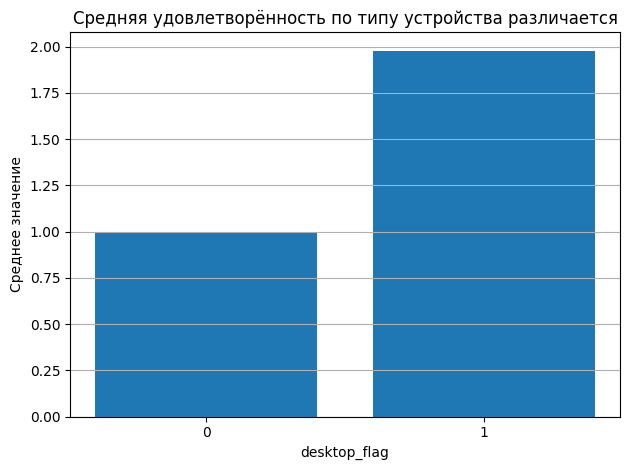

In [3]:
# генерировали в первом семинаре - зависит от desktop_flag

# агрегируем по нему
satisfaction_metric_by_desktop_flag = df.groupby("desktop_flag")['satisfaction_metric'].mean()

plt.bar(satisfaction_metric_by_desktop_flag.index, satisfaction_metric_by_desktop_flag.values)

plt.title("Средняя удовлетворённость по типу устройства различается")
plt.xlabel("desktop_flag")
plt.ylabel("Среднее значение")
plt.grid(axis='y')

plt.xticks([0, 1], ['0', '1'])
plt.tight_layout()
plt.show()

Q: Какая тут теорема работает? ЦПТ или ЗБЧ?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="400">

A: ЗБЧ

In [4]:
from statsmodels.stats.weightstats import ztest

# делим satisfaction_metric на две независимые группы
group_0 = df.loc[df["desktop_flag"] == 0, "satisfaction_metric"].dropna()
group_1 = df.loc[df["desktop_flag"] == 1, "satisfaction_metric"].dropna()


In [5]:

# H0: средняя satisfaction_metric одинаковая для desktop_flag = 0 и 1
# H1: средние различаются
z_stat, p_value = ztest(group_0, group_1, alternative="two-sided")

print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Отвергаем H0: средняя удовлетворённость статистически значимо различается.")
else:
    print("Не отвергаем H0: статистически значимого различия средних нет.")

z-statistic: -47.4058
p-value: 0.0000
Отвергаем H0: средняя удовлетворённость статистически значимо различается.


Q: А тут? ЦПТ или ЗБЧ?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="400">

A: ЦПТ

# 2. ROC-AUC

In [6]:
url = "https://raw.githubusercontent.com/polozkovdmitry/pda_dataset/refs/heads/main/2026_spring/sem_3_metrics/sessions_full_3.csv"

df = pd.read_csv(url)
print(df.sample(5))

        user_id   session_start_dttm  desktop_flag  session_duration_min  purchase_flag  purchase_amount_rub rfm_category      registered_dttm  male_flag  moscow_flag  age
107153    16335  2025-05-24 06:13:54             1                     9              0                    0     лояльные  2023-07-03 00:35:44          0            0   19
34525      6584  2024-04-03 14:23:45             1                     6              0                    0   неактивные  2024-02-09 08:14:14          1            0   42
134453    18731  2025-09-11 13:08:55             0                     4              1                  272     лояльные  2024-03-17 08:55:51          1            0   31
122540    69155  2025-07-27 08:41:45             1                     8              0                    0     лояльные  2024-03-19 16:50:52          1            0   24
101982    78350  2025-04-27 23:21:04             1                     8              0                    0     лояльные  2023-07-03 06:48:

In [7]:
df['purchased_flag'] = (df['purchase_amount_rub'] > 0)

## наивный бинарный классификатор

In [8]:
df["purchased_prob_model_naive"] = np.where(
    df["session_duration_min"] < 5,
    0.3,
    0.5
)

In [9]:
assert df['purchased_flag'].notna().all()
assert df['purchased_prob_model_naive'].notna().all()

y_true = df['purchased_flag']
y_score = df['purchased_prob_model_naive']

In [10]:
roc_auc = roc_auc_score(y_true, y_score)
print(roc_auc)

0.4975719354176329


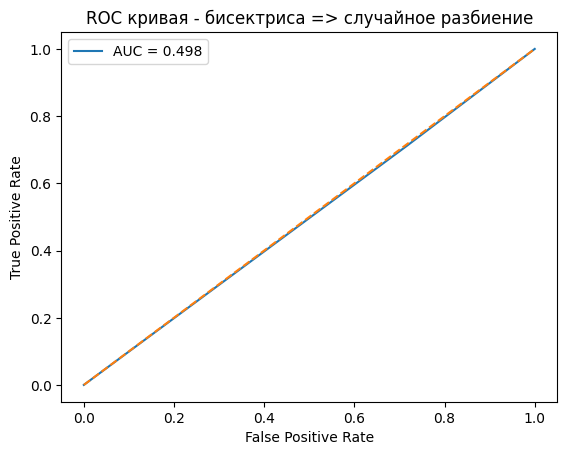

In [11]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая - бисектриса => случайное разбиение')
plt.legend()
plt.show()

## бинарный классификатор «эксперт»

In [12]:
purchase_prob = np.full(len(df), 0.4, dtype=float)

purchase_prob *= np.where(
    df["moscow_flag"].to_numpy() == 1,
    1.25,
    1.0
)

purchase_prob = np.clip(purchase_prob, 0.0, 1.0)
df["purchased_prob_model_expert"] = purchase_prob

In [13]:
y_score = df['purchased_prob_model_expert']

roc_auc = roc_auc_score(y_true, y_score)
print(roc_auc)

0.5421566245005918


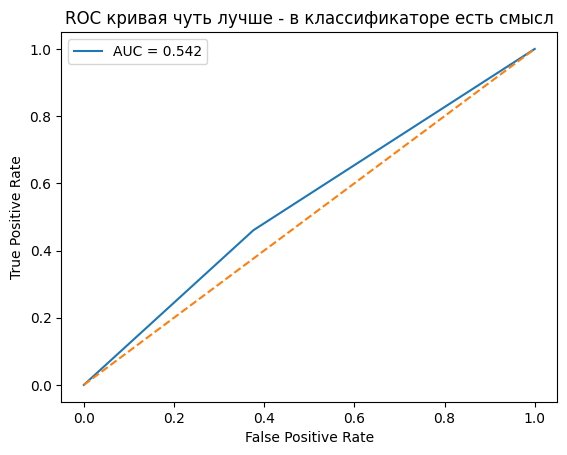

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая чуть лучше - в классификаторе есть смысл')
plt.legend()
plt.show()

## логрег <3

In [15]:
from sklearn.linear_model import LogisticRegression

features = [
    "desktop_flag",
    "session_duration_min",
    "moscow_flag",
    "age",
]

X = df[features]
y = df["purchase_flag"]

logreg = LogisticRegression(max_iter=1000)

logreg.fit(X, y)

df["purchased_prob_model_logreg"] = logreg.predict_proba(X)[:, 1]

In [16]:
y_score = df["purchased_prob_model_logreg"]

roc_auc = roc_auc_score(y_true, y_score)
print(roc_auc)

0.5463641322528403


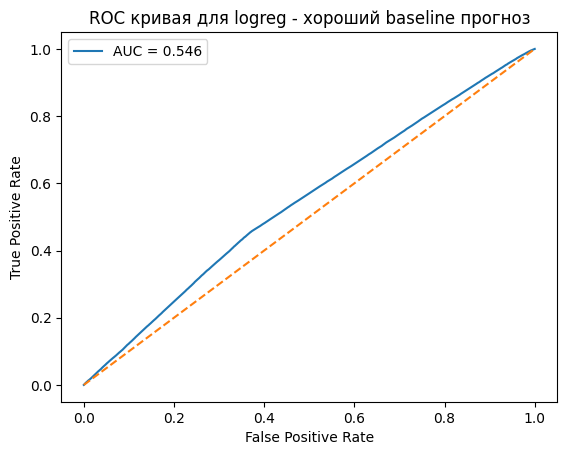

In [17]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая для logreg - хороший baseline прогноз')
plt.legend()
plt.show()

## руками

In [18]:
# задача: посчитать ROC-AUC для классификатора y_score

y_true  = [0, 0, 1, 1]
y_score = [0.10, 0.40, 0.35, 0.80]

In [19]:
# ответ

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

print("thresholds:", thresholds)
print("FPR:", fpr)
print("TPR:", tpr)
print("AUC:", auc)

thresholds: [ inf 0.8  0.4  0.35 0.1 ]
FPR: [0.  0.  0.5 0.5 1. ]
TPR: [0.  0.5 0.5 1.  1. ]
AUC: 0.75
